# Exercise 01: Image Processing with OpenCV
# Cluster 5 - Image, Audio, Text and Database Processing
# Framework: EU AI Act Article 52 (Transparency for Synthetic Content), Article 5 (Prohibited Practices)
# Case Study: NCII 🔴

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Create a synthetic face-like image (we don't use real faces - governance principle)
image = np.zeros((300, 300, 3), dtype=np.uint8)

# Draw a simple face shape
cv2.circle(image, (150, 150), 100, (255, 200, 150), -1)  # face
cv2.circle(image, (110, 120), 15, (50, 50, 50), -1)       # left eye
cv2.circle(image, (190, 120), 15, (50, 50, 50), -1)       # right eye
cv2.ellipse(image, (150, 180), (40, 20), 0, 0, 180, (50, 50, 50), 2)  # mouth

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)

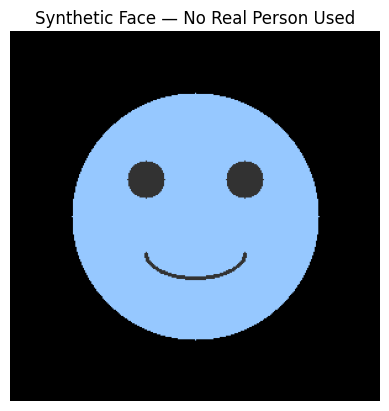

In [4]:
# Display the synthetic face
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)
plt.title('Synthetic Face — No Real Person Used')
plt.axis('off')
plt.show()

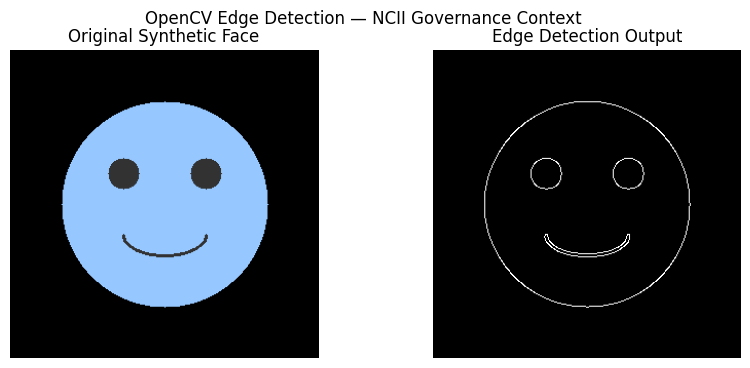

In [5]:
# Convert to grayscale first
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply edge detection
edges = cv2.Canny(gray, 100, 200)

# Display original and edges side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.imshow(image_rgb)
ax1.set_title('Original Synthetic Face')
ax1.axis('off')

ax2.imshow(edges, cmap='gray')
ax2.set_title('Edge Detection Output')
ax2.axis('off')

plt.suptitle('OpenCV Edge Detection — NCII Governance Context')
plt.show()

## Governance Reflection: Edge Detection and NCII Detection

Edge detection strips away color and texture, leaving only facial structure. This is how deepfake detection systems work — they compare extracted facial geometry against known real face proportions to identify synthetic or manipulated faces. 

However, deploying edge detection at scale raises a privacy question: scanning user uploads without explicit consent violates privacy rights, even if the goal is to prevent harm. Governance frameworks must require platforms to obtain upfront consent through transparent disclosure in terms of service, allow users to opt out (with documented restrictions), and ensure human review of flagged content. Additionally, the person whose face appears in flagged NCII must have the right to request removal and receive notification.

This reflects EU AI Act Article 52 (transparency for AI-generated content) and Article 22 (human review for high-risk decisions) — detection must be disclosed, not hidden from users.

In [7]:
# Check image metadata - governance relevance
print("Image shape:", image.shape)
print("Image dtype:", image.dtype)
print("Total pixels:", image.shape[0] * image.shape[1])
print("Color channels:", image.shape[2])

Image shape: (300, 300, 3)
Image dtype: uint8
Total pixels: 90000
Color channels: 3


## Technical Concept: EXIF Metadata and Evidence Preservation

EXIF (Exchangeable Image File Format) metadata includes creation date, device model, GPS location, and software used to create or edit an image. For NCII, this metadata serves two critical governance functions:

1. **Detection:** EXIF data reveals if an image was generated by AI software (generative tools leave signatures in metadata)
2. **Accountability:** Metadata proves when content was created, from which device, and by which user account

However, perpetrators can strip EXIF data before sharing, and platforms often delete metadata when accounts are removed. A governance framework must require platforms to preserve metadata on flagged content in secure audit logs — separate from the account itself — so that evidence exists even if the perpetrator deletes their account.

This is critical for law enforcement investigation and victim accountability.